In [2]:
# Loading the data

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

url = "https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv"
full_df = pd.read_csv(url)

# Select only the required columns
df_clusters = full_df[["Latitude", "Longitude", "MedInc"]]

# Split into Train and Test (80/20 split)
X_train, X_test = train_test_split(df_clusters, test_size=0.2, random_state=42)

# Scale the data
# K-Means uses distance, all features must be on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier viewing
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# --- RESULTS ---
print("Step 1 Results:")
print(f"Total Rows: {len(full_df)}")
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print("\nFirst 5 rows of Scaled Training Data:")
print(X_train_scaled_df.head())

Step 1 Results:
Total Rows: 20640
Training set size: 16512 rows
Testing set size: 4128 rows

First 5 rows of Scaled Training Data:
   Latitude  Longitude    MedInc
0 -1.372811   1.272587 -0.326196
1 -0.876696   0.709162 -0.035843
2 -0.460146  -0.447603  0.144701
3 -1.382172   1.232698 -1.017864
4  0.532084  -0.108551 -0.171488


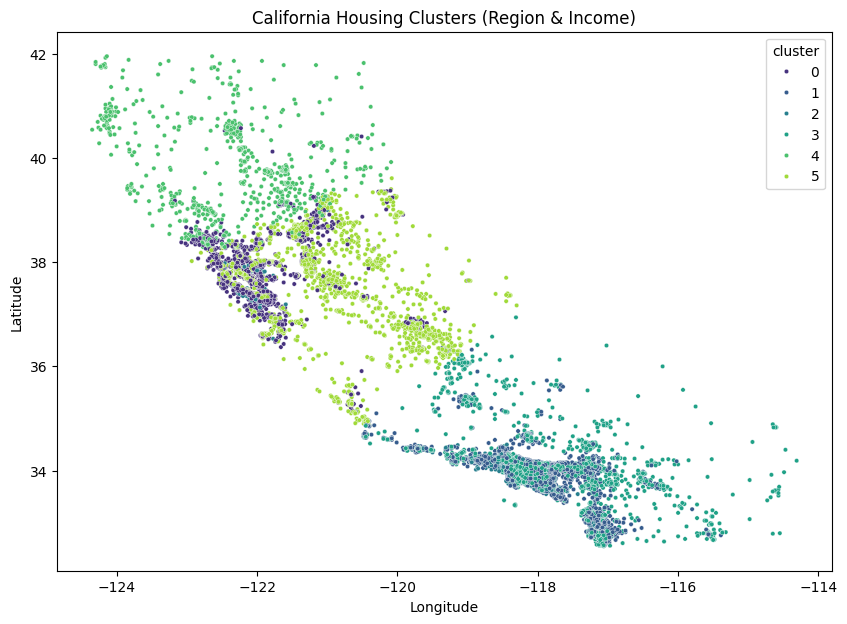

Step 2 Results:
       Latitude  Longitude  MedInc cluster
14196     32.71    -117.03  3.2596       3
8267      33.77    -118.16  3.8125       3
17445     34.66    -120.48  4.1563       1
14265     32.69    -117.11  1.9425       3
2271      36.78    -119.80  3.5542       5

Cluster Distribution:
cluster
3    5421
5    3598
1    3554
0    2474
4     982
2     483
Name: count, dtype: int64


In [4]:
# Build a K-means

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Initialize the K-Means model with 6 clusters
model = KMeans(n_clusters=6, random_state=42)

# Fit the model using the scaled training data
model.fit(X_train_scaled)

# Predict clusters for the training data and add as a new column
X_train["cluster"] = model.predict(X_train_scaled)

# Categorize the cluster column
X_train["cluster"] = X_train["cluster"].astype("category")

# --- VISUALIZATION ---

# Create a scatter plot to visualize the clusters 
plt.figure(figsize=(10, 7))
sns.scatterplot(data=X_train, x="Longitude", y="Latitude", hue="cluster", palette="viridis", s=10)
plt.title("California Housing Clusters (Region & Income)")
plt.show()

# --- RESULTS ---
print("Step 2 Results:")
print(X_train.head())
print("\nCluster Distribution:")
print(X_train["cluster"].value_counts())

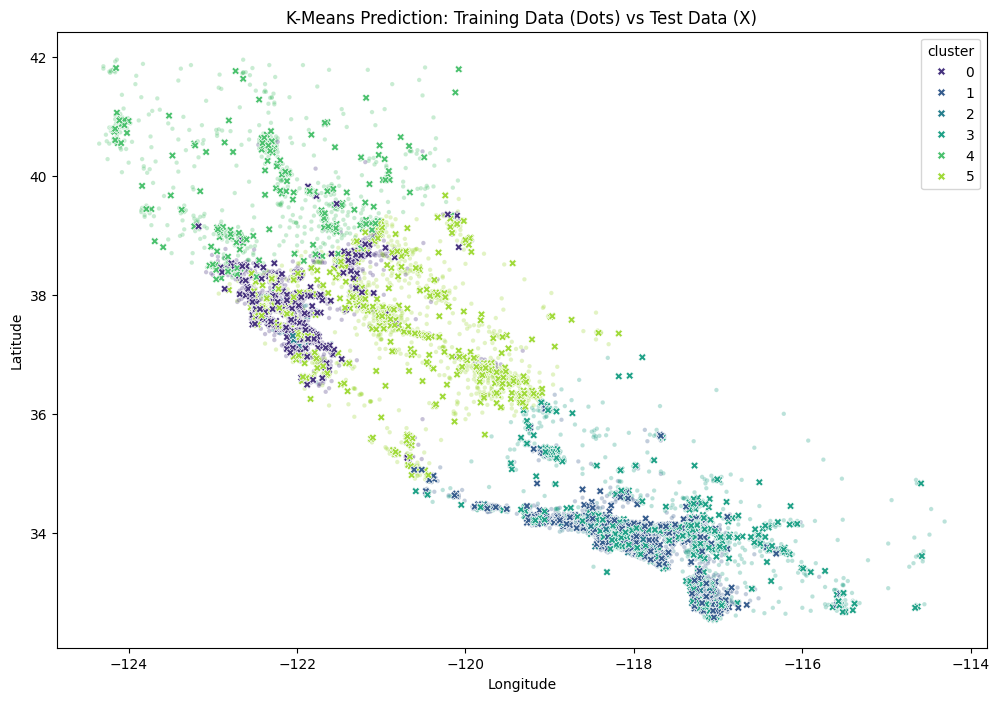

Step 3 Results:
Test data cluster assignment complete.
       Latitude  Longitude  MedInc cluster
20046     36.06    -119.01  1.6812       3
3024      35.14    -119.46  2.5313       3
15663     37.80    -122.44  3.4801       5
20484     34.28    -118.72  5.7376       1
9814      36.62    -121.93  3.7250       5


In [6]:
# Predict with the test set

# Predict clusters for the scaled test data
X_test["cluster"] = model.predict(X_test_scaled)

# Categorize the cluster column for the test set
X_test["cluster"] = X_test["cluster"].astype("category")

# --- VISUALIZATION ---

# Create a combined plot to compare Train vs Test
plt.figure(figsize=(12, 8))

# Plot training points 
sns.scatterplot(data=X_train, x="Longitude", y="Latitude", hue="cluster", 
                palette="viridis", s=10, alpha=0.3, legend=False)

# Plot test points with full opacity and a different marker ('X') to stand out
sns.scatterplot(data=X_test, x="Longitude", y="Latitude", hue="cluster", 
                palette="viridis", s=30, marker="X")

plt.title("K-Means Prediction: Training Data (Dots) vs Test Data (X)")
plt.show()

# --- RESULTS ---
print("Step 3 Results:")
print(f"Test data cluster assignment complete.")
print(X_test[["Latitude", "Longitude", "MedInc", "cluster"]].head())

In [7]:
# Train a supervised classification model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Random Forest Classifier
supervised_model = RandomForestClassifier(random_state=42)

# Train the model using the scaled training features and the cluster labels
# X_train_scaled (features) and X_train["cluster"] (target)
supervised_model.fit(X_train_scaled, X_train["cluster"])

# Predict the clusters for the test set
y_pred = supervised_model.predict(X_test_scaled)

# Calculate and print the accuracy
accuracy = accuracy_score(X_test["cluster"], y_pred)
print(f"Step 4 Results:")
print(f"Supervised Model Accuracy: {accuracy:.4f}")

# Print a detailed classification report
print("\nClassification Report:")
print(classification_report(X_test["cluster"], y_pred))

Step 4 Results:
Supervised Model Accuracy: 0.9949

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       557
           1       1.00      1.00      1.00       897
           2       1.00      0.97      0.99       116
           3       1.00      1.00      1.00      1397
           4       0.98      0.99      0.99       246
           5       0.99      0.99      0.99       915

    accuracy                           0.99      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       0.99      0.99      0.99      4128



In [8]:
# Save the models

import pickle

# Save the K-Means model to a file
with open("kmeans_model.sav", "wb") as f:
    pickle.dump(model, f)

# Save the Random Forest model to a file
with open("random_forest_classifier.sav", "wb") as f:
    pickle.dump(supervised_model, f)

# --- RESULTS ---
print("Step 5 Results:")
print("Both models have been saved successfully to the project folder.")


Step 5 Results:
Both models have been saved successfully to the project folder.
